# Notebook 03 — Segmentación RFM Avanzada: K-Means + BG/NBD

**Dataset:** Online Retail II (UCI)  
**Periodo:** Diciembre 2009 – Diciembre 2011  
**Clientes:** 5.862 | **Transacciones limpias:** 802.949

---

### Objetivos del notebook
1. Calcular métricas RFM clásicas a nivel cliente.
2. Aplicar clustering K-Means con selección óptima de K (Elbow + Silhouette).
3. Ajustar el modelo probabilístico BG/NBD para predecir compras futuras.
4. Estimar el Gamma-Gamma para CLV monetario.
5. Combinar segmentos K-Means con predicciones BG/NBD en un perfil de cliente 360°.
6. Exportar resultados y visualizaciones para el portfolio.

---
### Referencias
- Fader, Hardie & Lee (2005) — *Counting Your Customers the Easy Way*  
- lifetimes library: https://lifetimes.readthedocs.io

## 0 · Setup y librerías

In [7]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ── Lifetimes (BG/NBD + Gamma-Gamma) ─────────────────────────────────────────
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)
from lifetimes.utils import summary_data_from_transaction_data

# ── Configuración visual ──────────────────────────────────────────────────────
PALETTE = {
    'primary':   '#2563EB',
    'secondary': '#7C3AED',
    'accent':    '#F59E0B',
    'success':   '#10B981',
    'danger':    '#EF4444',
    'neutral':   '#6B7280',
}
SEGMENT_COLORS = [
    '#2563EB', '#7C3AED', '#10B981', '#F59E0B',
    '#EF4444', '#06B6D4', '#D97706', '#6B7280'
]

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('data/processed')
OUTPUT_DIR  = Path('outputs/03_rfm')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Entorno listo.')

✅ Entorno listo.


## 1 · Carga de datos

In [8]:
import os
from pathlib import Path

# Sube al directorio raíz del proyecto automáticamente
notebook_dir = Path.cwd()
print("Directorio actual:", notebook_dir)

# Si el notebook está en /notebooks, sube un nivel
if notebook_dir.name == 'notebooks':
    os.chdir(notebook_dir.parent)
    print("Cambiado a:", Path.cwd())

Directorio actual: c:\Users\esthe\Desktop\Repository\customer-decision-intelligence


In [9]:
DATA_DIR   = Path('data/processed')
OUTPUT_DIR = Path('outputs/03_rfm')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verificación
print("¿Archivo encontrado?:", (DATA_DIR / 'transactions_clean.parquet').exists())

¿Archivo encontrado?: True


In [10]:
df = pd.read_parquet(DATA_DIR / 'transactions_clean.parquet')

# Asegurar tipos correctos
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue']     = df['Quantity'] * df['Price']

print(f"Filas: {len(df):,.0f}")
print(f"Clientes únicos: {df['Customer ID'].nunique():,.0f}")
print(f"Periodo: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head(3)

Filas: 802,949
Clientes únicos: 5,862
Periodo: 2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


## 2 · Cálculo de métricas RFM

Usamos como **fecha de snapshot** el día siguiente al último registro para calcular Recency de forma consistente.

In [11]:
SNAPSHOT_DATE = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

# ── RFM por cliente ────────────────────────────────────────────────────────────
rfm = (
    df.groupby('Customer ID')
    .agg(
        last_purchase  = ('InvoiceDate', 'max'),
        frequency      = ('Invoice', 'nunique'),   # nº de órdenes únicas
        monetary       = ('Revenue', 'sum'),
        n_items        = ('Quantity', 'sum'),       # feature extra
        avg_order_value= ('Revenue', lambda x: x.groupby(
            df.loc[x.index, 'Invoice']).sum().mean()),
    )
    .reset_index()
)

rfm['recency'] = (SNAPSHOT_DATE - rfm['last_purchase']).dt.days
rfm = rfm.drop(columns='last_purchase')

# Eliminar outliers extremos (clientes con monetary < 0 → devoluciones netas)
rfm = rfm[rfm['monetary'] > 0].copy()
rfm = rfm[rfm['frequency'] >= 1].copy()

print(f"\nClientes en RFM: {len(rfm):,.0f}")
rfm[['recency','frequency','monetary']].describe().round(2)

Snapshot date: 2011-12-10

Clientes en RFM: 5,862


,recency,frequency,monetary
count,5862.00,5862.00,5862.00
mean,200.99,6.25,2977.10
std,209.22,12.79,14627.03
min,1.00,1.00,2.95
25%,26.00,1.00,344.64
50%,96.00,3.00,880.63
75%,379.00,7.00,2286.34
max,739.00,378.00,608821.65


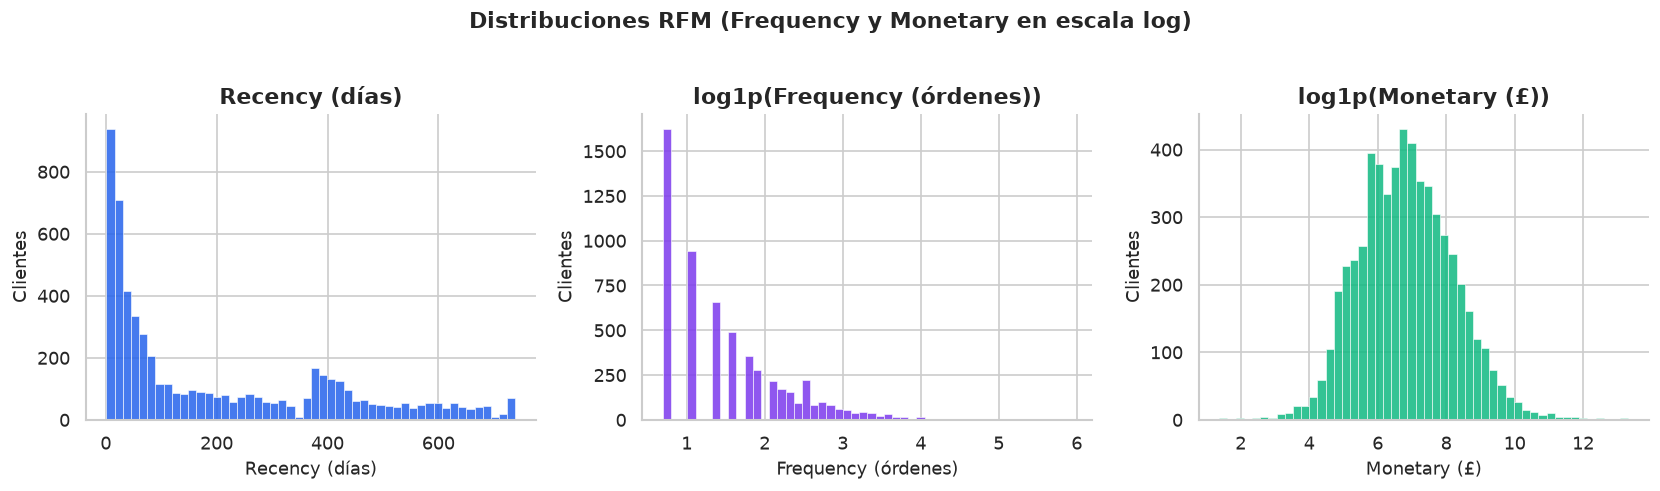

In [12]:
# ── Visualización distribuciones RFM ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ('recency',   'Recency (días)',          PALETTE['primary']),
    ('frequency', 'Frequency (órdenes)',     PALETTE['secondary']),
    ('monetary',  'Monetary (£)',            PALETTE['success']),
]

for ax, (col, label, color) in zip(axes, metrics):
    data = np.log1p(rfm[col]) if col in ('frequency', 'monetary') else rfm[col]
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    prefix = 'log1p(' if col in ('frequency', 'monetary') else ''
    suffix = ')' if prefix else ''
    ax.set_title(f'{prefix}{label}{suffix}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Clientes')

plt.suptitle('Distribuciones RFM (Frequency y Monetary en escala log)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rfm_distributions.png', bbox_inches='tight')
plt.show()

### 2.1 Scoring RFM clásico (quintiles)

Asignamos scores del 1 al 5 por quintil para la interpretación de negocio, independientemente del clustering.

In [13]:
# Recency: menor = mejor → invertimos
rfm['R_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score'] * 100 + rfm['F_score'] * 10 + rfm['M_score']
rfm['RFM_total'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

# Segmento descriptivo basado en R y F
def rfm_segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4:   return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r >= 3 and f <= 2: return 'Potential Loyalists'
    elif r == 2:            return 'At Risk'
    elif r == 1 and f >= 3: return 'Can\'t Lose Them'
    else:                   return 'Lost'

rfm['RFM_segment'] = rfm.apply(rfm_segment, axis=1)

seg_counts = rfm['RFM_segment'].value_counts()
print(seg_counts.to_string())

RFM_segment
Champions              1477
Loyal                  1212
At Risk                1169
Lost                    896
New Customers           451
Potential Loyalists     380
Can't Lose Them         277


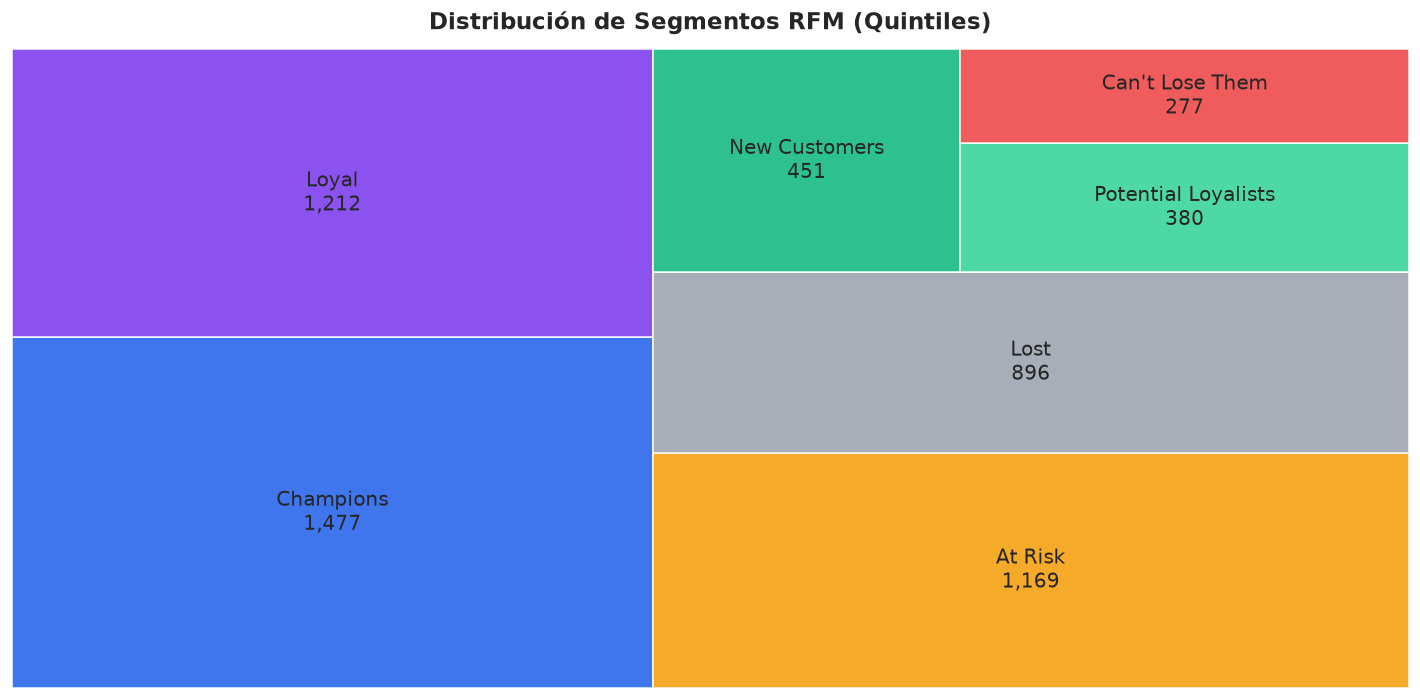

In [14]:
# ── Treemap de segmentos RFM ──────────────────────────────────────────────────
try:
    import squarify
    HAS_SQUARIFY = True
except ImportError:
    HAS_SQUARIFY = False

seg_colors_map = {
    'Champions':           '#2563EB',
    'Loyal':               '#7C3AED',
    'New Customers':       '#10B981',
    'Potential Loyalists': '#34D399',
    'At Risk':             '#F59E0B',
    "Can't Lose Them":     '#EF4444',
    'Lost':                '#9CA3AF',
}

if HAS_SQUARIFY:
    sizes  = seg_counts.values
    labels = [f"{s}\n{n:,}" for s, n in zip(seg_counts.index, seg_counts.values)]
    colors = [seg_colors_map.get(s, '#ccc') for s in seg_counts.index]
    fig, ax = plt.subplots(figsize=(12, 6))
    squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.88, ax=ax)
    ax.axis('off')
    ax.set_title('Distribución de Segmentos RFM (Quintiles)', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'rfm_treemap.png', bbox_inches='tight')
    plt.show()
else:
    # Fallback: barplot
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [seg_colors_map.get(s, '#ccc') for s in seg_counts.index]
    ax.barh(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
    ax.set_xlabel('Número de clientes')
    ax.set_title('Segmentos RFM (Quintiles)', fontweight='bold')
    for i, v in enumerate(seg_counts.values):
        ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'rfm_segments_bar.png', bbox_inches='tight')
    plt.show()
    print("💡 Instala squarify para el treemap: pip install squarify")

## 3 · Clustering K-Means

### 3.1 Preprocesamiento para clustering

In [15]:
# Features para clustering: RFM + avg_order_value
CLUSTER_FEATURES = ['recency', 'frequency', 'monetary', 'avg_order_value']

X_raw = rfm[CLUSTER_FEATURES].copy()

# Log1p para reducir skewness de frequency y monetary
X_log = X_raw.copy()
for col in ['frequency', 'monetary', 'avg_order_value']:
    X_log[col] = np.log1p(X_log[col])

# RobustScaler (resistente a outliers)
scaler  = RobustScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=rfm.index)

print("Features escaladas (muestra):")
pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES).describe().round(3)

Features escaladas (muestra):


,recency,frequency,monetary,avg_order_value
count,5862.000,5862.000,5862.000,5862.000
mean,0.297,0.115,0.023,-0.026
std,0.593,0.583,0.733,0.871
min,-0.269,-0.500,-2.862,-5.087
25%,-0.198,-0.500,-0.495,-0.539
50%,0.000,0.000,-0.000,0.000
75%,0.802,0.500,0.505,0.461
max,1.822,3.283,3.459,6.769


### 3.2 Selección óptima de K — Elbow + Silhouette + Davies-Bouldin

In [16]:
K_RANGE = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"K={k:2d} | Inertia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f} | DB={db_scores[-1]:.4f}")

K= 2 | Inertia=7,038 | Silhouette=0.3425 | DB=1.0961
K= 3 | Inertia=5,576 | Silhouette=0.2754 | DB=1.2016
K= 4 | Inertia=4,594 | Silhouette=0.2858 | DB=1.1010
K= 5 | Inertia=3,920 | Silhouette=0.2929 | DB=1.0556
K= 6 | Inertia=3,448 | Silhouette=0.2813 | DB=1.0202
K= 7 | Inertia=3,090 | Silhouette=0.2706 | DB=1.0177
K= 8 | Inertia=2,787 | Silhouette=0.2755 | DB=0.9898
K= 9 | Inertia=2,544 | Silhouette=0.2808 | DB=0.9905
K=10 | Inertia=2,354 | Silhouette=0.2716 | DB=0.9738


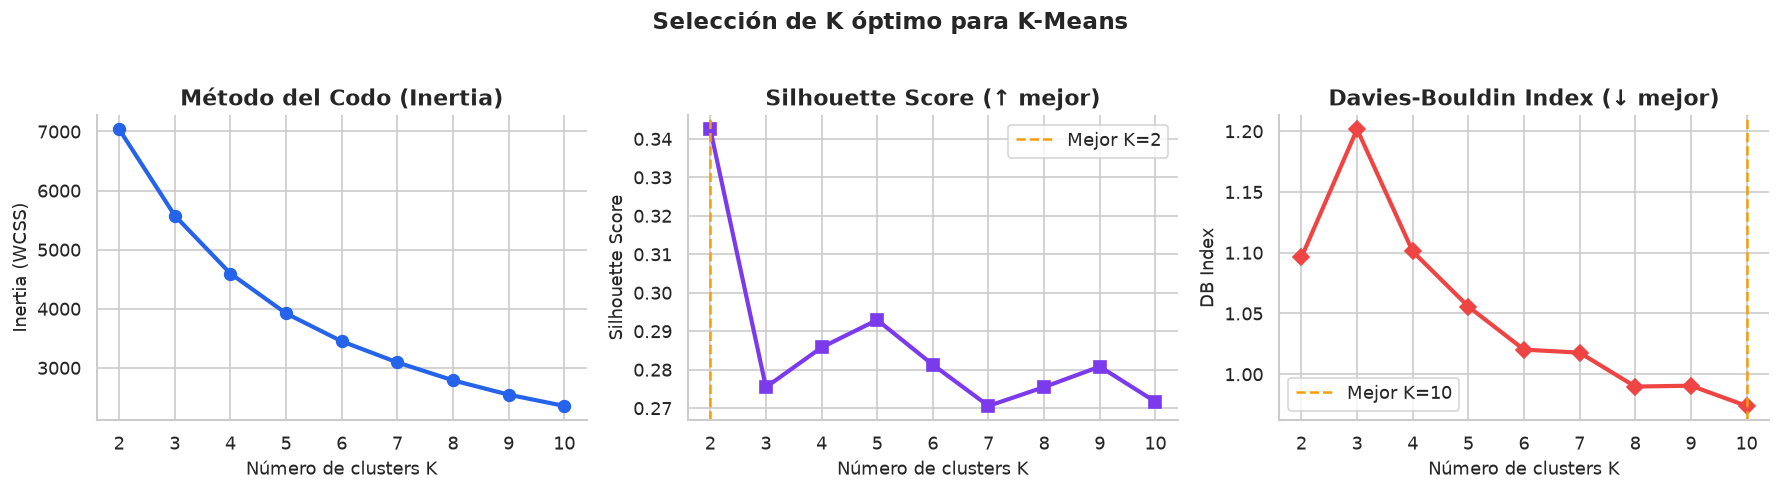


→ Mejor K por Silhouette: 2
→ Mejor K por Davies-Bouldin: 10


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elbow
axes[0].plot(K_RANGE, inertias, 'o-', color=PALETTE['primary'], linewidth=2.5, markersize=7)
axes[0].set_title('Método del Codo (Inertia)', fontweight='bold')
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(K_RANGE, silhouettes, 's-', color=PALETTE['secondary'], linewidth=2.5, markersize=7)
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, linestyle='--', color=PALETTE['accent'], linewidth=1.5, label=f'Mejor K={best_k_sil}')
axes[1].set_title('Silhouette Score (↑ mejor)', fontweight='bold')
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

# Davies-Bouldin
axes[2].plot(K_RANGE, db_scores, 'D-', color=PALETTE['danger'], linewidth=2.5, markersize=7)
best_k_db = list(K_RANGE)[np.argmin(db_scores)]
axes[2].axvline(best_k_db, linestyle='--', color=PALETTE['accent'], linewidth=1.5, label=f'Mejor K={best_k_db}')
axes[2].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold')
axes[2].set_xlabel('Número de clusters K')
axes[2].set_ylabel('DB Index')
axes[2].set_xticks(list(K_RANGE))
axes[2].legend()

plt.suptitle('Selección de K óptimo para K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_k_selection.png', bbox_inches='tight')
plt.show()

print(f"\n→ Mejor K por Silhouette: {best_k_sil}")
print(f"→ Mejor K por Davies-Bouldin: {best_k_db}")

### 3.3 Ajuste del modelo final

In [18]:
# ── Elegir K final ──────────────────────────────────────────────────────────
# Ajusta K_OPTIMAL según las métricas vistas arriba.
# Valor por defecto que suele funcionar bien en datasets retail: 4
K_OPTIMAL = best_k_sil  # puedes cambiar manualmente si prefieres otro valor

km_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=50, random_state=42)
rfm['cluster'] = km_final.fit_predict(X_scaled)

print(f"K elegido: {K_OPTIMAL}")
print(f"Silhouette final: {silhouette_score(X_scaled, rfm['cluster'], random_state=42):.4f}")
print("\nDistribución de clusters:")
print(rfm['cluster'].value_counts().sort_index().to_string())

K elegido: 2
Silhouette final: 0.3416

Distribución de clusters:
cluster
0    2983
1    2879


### 3.4 Perfilado de clusters

In [19]:
cluster_profile = (
    rfm.groupby('cluster')
    .agg(
        n_customers    = ('Customer ID', 'count'),
        recency_med    = ('recency',   'median'),
        frequency_med  = ('frequency', 'median'),
        monetary_med   = ('monetary',  'median'),
        monetary_sum   = ('monetary',  'sum'),
        aov_med        = ('avg_order_value', 'median'),
    )
    .round(1)
)

cluster_profile['revenue_pct'] = (
    cluster_profile['monetary_sum'] / cluster_profile['monetary_sum'].sum() * 100
).round(1)

print(cluster_profile.to_string())

         n_customers  recency_med  frequency_med  monetary_med  monetary_sum  aov_med  revenue_pct
cluster                                                                                           
0               2983         42.0            6.0        2241.7    16304599.2    387.4         93.4
1               2879        308.0            2.0         338.1     1147157.1    188.8          6.6


In [20]:
# ── Etiquetas de negocio para los clusters ─────────────────────────────────
# Las etiquetas se asignan según el perfil observado en cluster_profile.
# IMPORTANTE: revisa cluster_profile y ajusta este diccionario si tu K ≠ 4.

CLUSTER_LABELS = {
    0: 'Champions',        # Alta F, alta M, baja R
    1: 'At Risk',          # Alta F pasada, alta R (inactivos)
    2: 'Promising',        # Media F, media M
    3: 'Lost / Hibernating',# Baja F, alta R, baja M
}
# Si K_OPTIMAL != 4, amplía el diccionario:
for k in range(K_OPTIMAL):
    if k not in CLUSTER_LABELS:
        CLUSTER_LABELS[k] = f'Segment {k}'

rfm['cluster_label'] = rfm['cluster'].map(CLUSTER_LABELS)
cluster_profile['label'] = cluster_profile.index.map(CLUSTER_LABELS)
print("Etiquetas asignadas:")
for k, v in CLUSTER_LABELS.items():
    print(f"  Cluster {k}: {v}")

Etiquetas asignadas:
  Cluster 0: Champions
  Cluster 1: At Risk
  Cluster 2: Promising
  Cluster 3: Lost / Hibernating


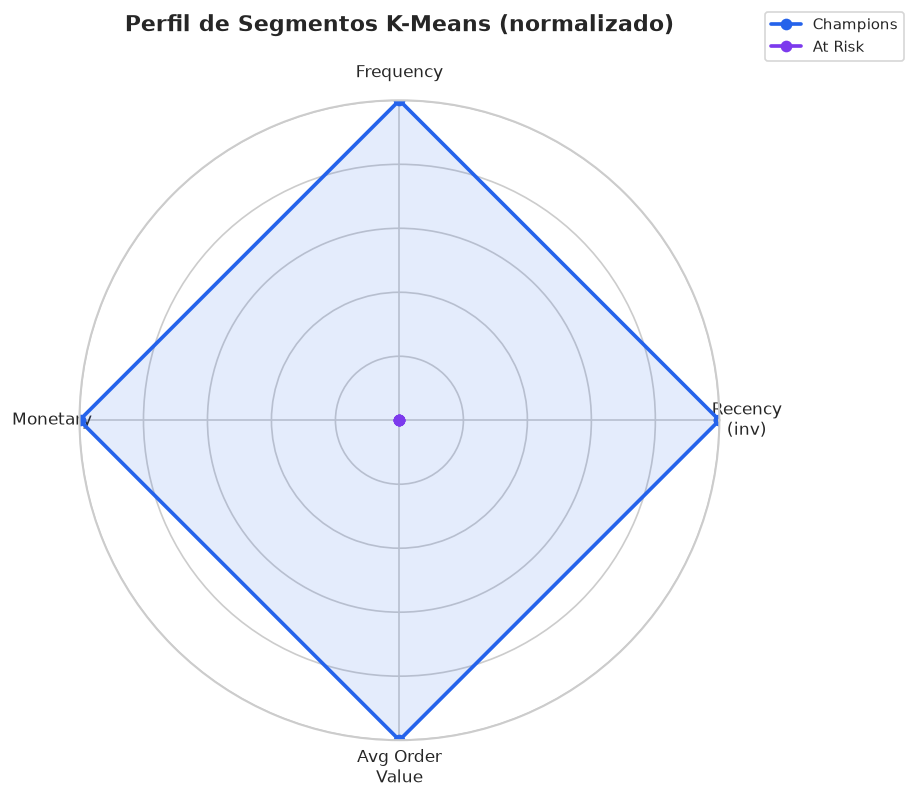

In [21]:
# ── Radar chart de perfiles ───────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

# Normalizar métricas al rango [0,1] para el radar
radar_metrics  = ['recency_med', 'frequency_med', 'monetary_med', 'aov_med']
radar_labels   = ['Recency\n(inv)', 'Frequency', 'Monetary', 'Avg Order\nValue']

radar_data = cluster_profile[radar_metrics].copy()
radar_data['recency_med'] = radar_data['recency_med'].max() - radar_data['recency_med']  # invertir recency
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N  = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    color  = SEGMENT_COLORS[i % len(SEGMENT_COLORS)]
    label  = CLUSTER_LABELS.get(idx, f'Cluster {idx}')
    ax.plot(angles, values, 'o-', linewidth=2.2, color=color, label=label)
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title('Perfil de Segmentos K-Means (normalizado)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_radar_profile.png', bbox_inches='tight')
plt.show()

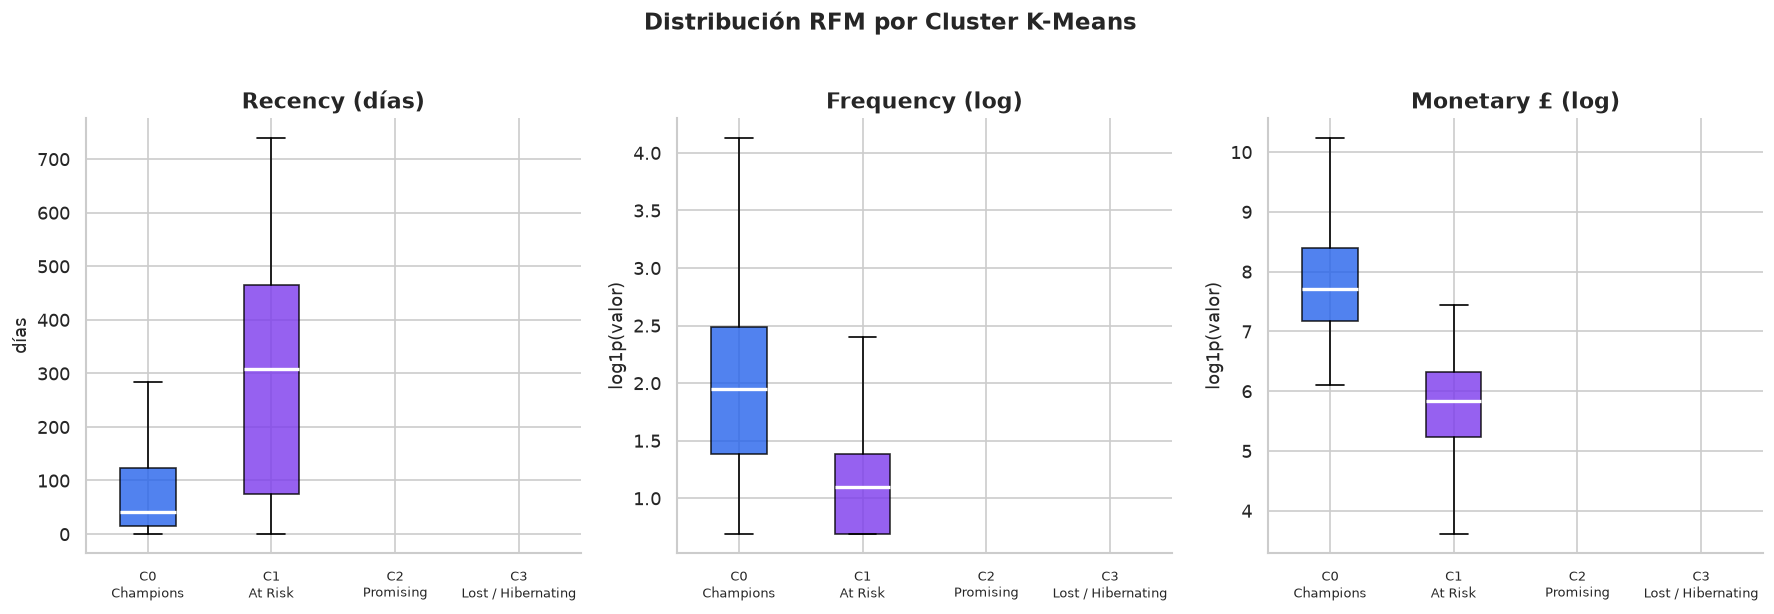

In [22]:
# ── Box plots por cluster ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

box_pairs = [
    ('recency',   'Recency (días)',  False),
    ('frequency', 'Frequency (log)', True),
    ('monetary',  'Monetary £ (log)',True),
]

for ax, (col, ylabel, log_scale) in zip(axes, box_pairs):
    plot_data = []
    tick_labels = []
    colors_box = []
    for i, (k, lbl) in enumerate(CLUSTER_LABELS.items()):
        vals = rfm.loc[rfm['cluster'] == k, col].values
        if log_scale:
            vals = np.log1p(vals)
        plot_data.append(vals)
        tick_labels.append(f"C{k}\n{lbl}")
        colors_box.append(SEGMENT_COLORS[i % len(SEGMENT_COLORS)])

    bp = ax.boxplot(plot_data, patch_artist=True, showfliers=False, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_ylabel('log1p(valor)' if log_scale else 'días')

plt.suptitle('Distribución RFM por Cluster K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_boxplots.png', bbox_inches='tight')
plt.show()

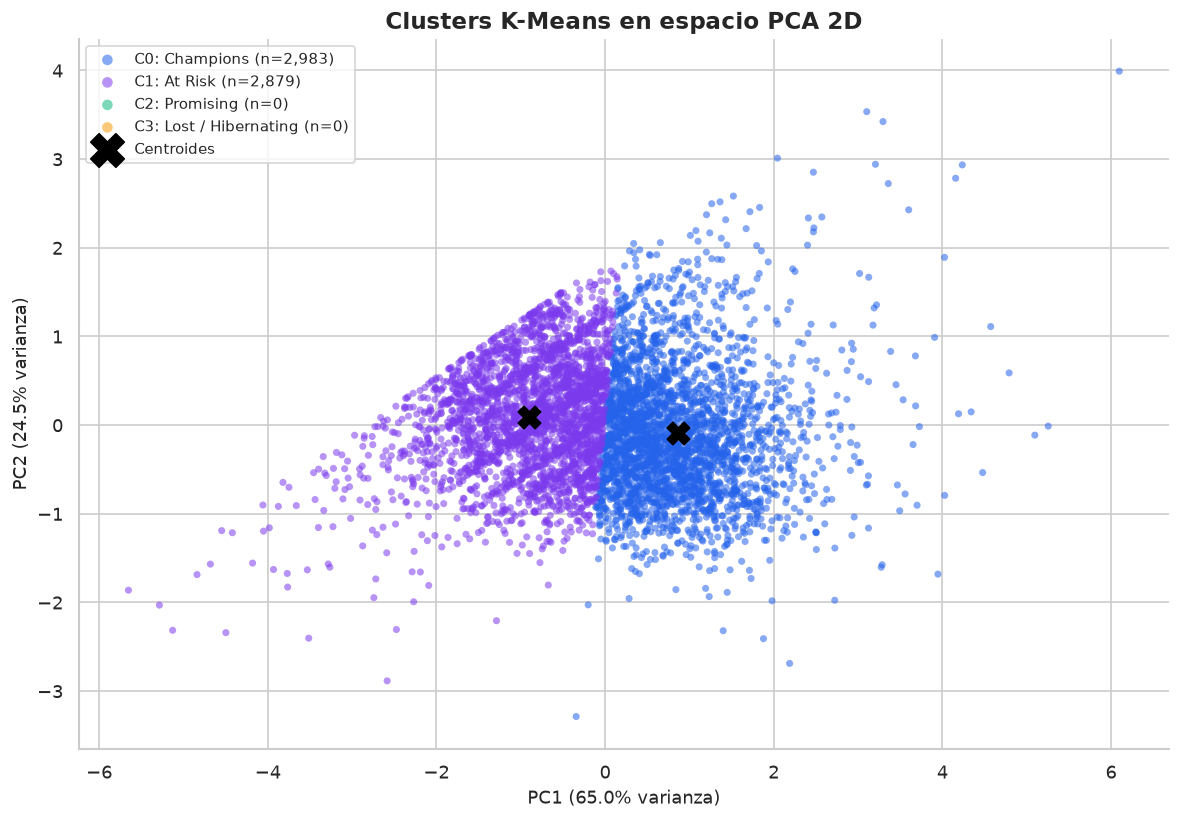

Varianza explicada acumulada (PC1+PC2): 89.5%


In [23]:
# ── Visualización 2D con PCA ──────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))

for i, (k, lbl) in enumerate(CLUSTER_LABELS.items()):
    mask = rfm['cluster'] == k
    ax.scatter(
        X_pca[mask.values, 0], X_pca[mask.values, 1],
        c=SEGMENT_COLORS[i % len(SEGMENT_COLORS)],
        label=f'C{k}: {lbl} (n={mask.sum():,})',
        alpha=0.55, s=18, edgecolors='none'
    )

# Centroides
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=180, zorder=5, label='Centroides'
)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Clusters K-Means en espacio PCA 2D', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, markerscale=1.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmeans_pca_scatter.png', bbox_inches='tight')
plt.show()
print(f"Varianza explicada acumulada (PC1+PC2): {sum(var_explained)*100:.1f}%")

## 4 · Modelo BG/NBD (Beta-Geometric / Negative Binomial Distribution)

El modelo BG/NBD (Fader et al., 2005) modela **dos procesos latentes** por cliente:
- **Compras**: proceso NBD — el cliente compra a una tasa $\lambda$ que varía entre clientes siguiendo una distribución Gamma.
- **Churn**: proceso BG — el cliente puede "morir" (dejar de comprar) con probabilidad $p$ después de cada transacción.

Los parámetros del modelo se estiman por máxima verosimilitud con la librería `lifetimes`.

### 4.1 Preparar datos para lifetimes

In [24]:
# summary_data_from_transaction_data genera la tabla (frequency, recency, T, monetary_value)
# en el formato requerido por lifetimes

# Usar sólo la columna de Revenue por transacción (línea nivel Invoice)
df_lt = df.groupby(['Customer ID', 'Invoice', 'InvoiceDate'])['Revenue'].sum().reset_index()
df_lt = df_lt[df_lt['Revenue'] > 0]  # excluir devoluciones

summary = summary_data_from_transaction_data(
    df_lt,
    customer_id_col   = 'Customer ID',
    datetime_col      = 'InvoiceDate',
    monetary_value_col= 'Revenue',
    observation_period_end= SNAPSHOT_DATE,
    freq              = 'D'
)

# Filtrar clientes con al menos 1 compra de repetición para BG/NBD
# (customers with frequency=0 sólo tienen 1 compra, se usan para predicción)
print(f"Total clientes en summary: {len(summary):,}")
print(f"Con freq > 0 (repetidores): {(summary['frequency'] > 0).sum():,}")
summary.describe().round(2)

Total clientes en summary: 5,862
Con freq > 0 (repetidores): 4,181


,frequency,recency,T,monetary_value
count,5862.00,5862.00,5862.00,5862.00
mean,4.61,273.53,475.05,316.82
std,9.93,258.68,223.18,2257.86
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,313.00,0.00
50%,2.00,222.00,530.00,213.00
75%,5.00,511.75,669.00,374.58
max,249.00,738.00,739.00,168469.60


### 4.2 Ajuste BG/NBD

In [25]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    summary['frequency'],
    summary['recency'],
    summary['T'],
    verbose=True
)

print("\n── Parámetros BG/NBD ──────────────────────────────────────")
print(bgf.summary.round(4).to_string())

Optimization terminated successfully.
         Current function value: -6.882507
         Iterations: 26
         Function evaluations: 27
         Gradient evaluations: 27

── Parámetros BG/NBD ──────────────────────────────────────
          coef  se(coef)  lower 95% bound  upper 95% bound
r       0.6674    0.0159           0.6362           0.6987
alpha  63.6681    1.9510          59.8442          67.4920
a       0.0751    0.0076           0.0602           0.0900
b       1.2397    0.1512           0.9433           1.5361


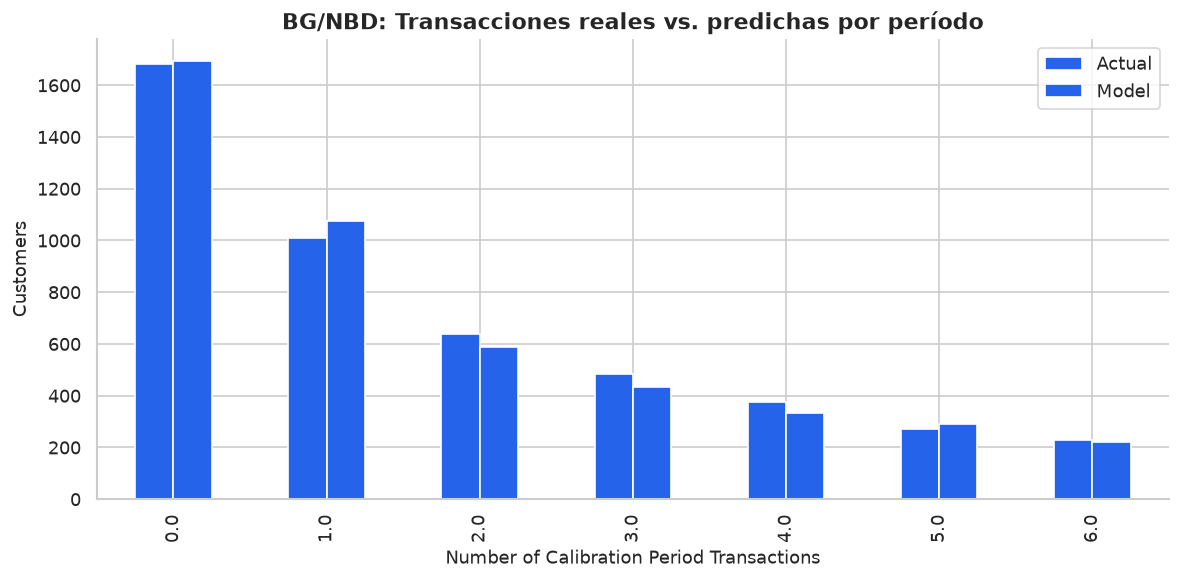

In [26]:
# ── Validación visual: transacciones reales vs esperadas ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
plot_period_transactions(bgf, ax=ax, color=PALETTE['primary'])
ax.set_title('BG/NBD: Transacciones reales vs. predichas por período', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bgnbd_period_transactions.png', bbox_inches='tight')
plt.show()

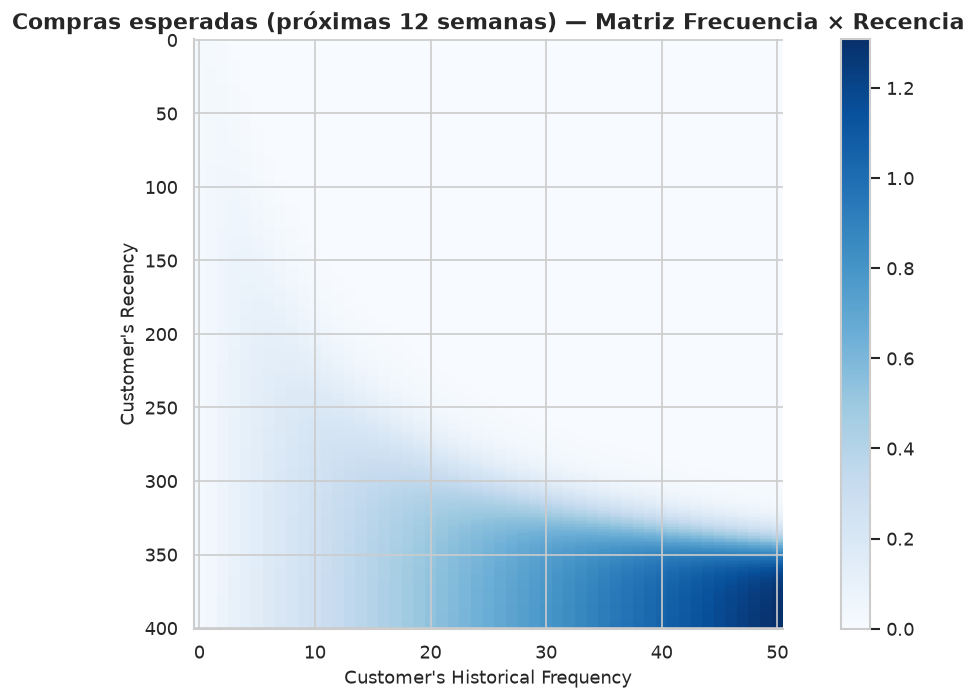

In [28]:
# ── Matriz Frequency-Recency (compras esperadas en próximas 12 semanas) ───────
fig, ax = plt.subplots(figsize=(10, 6))
plot_frequency_recency_matrix(
    bgf, T=12,
    max_frequency=50, max_recency=400,
    cmap='Blues'
    # ← quitamos ax=ax, lo gestiona internamente
)
ax = plt.gca()  # capturamos el ax después
ax.set_title('Compras esperadas (próximas 12 semanas) — Matriz Frecuencia × Recencia', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bgnbd_frequency_recency_matrix.png', bbox_inches='tight')
plt.show()

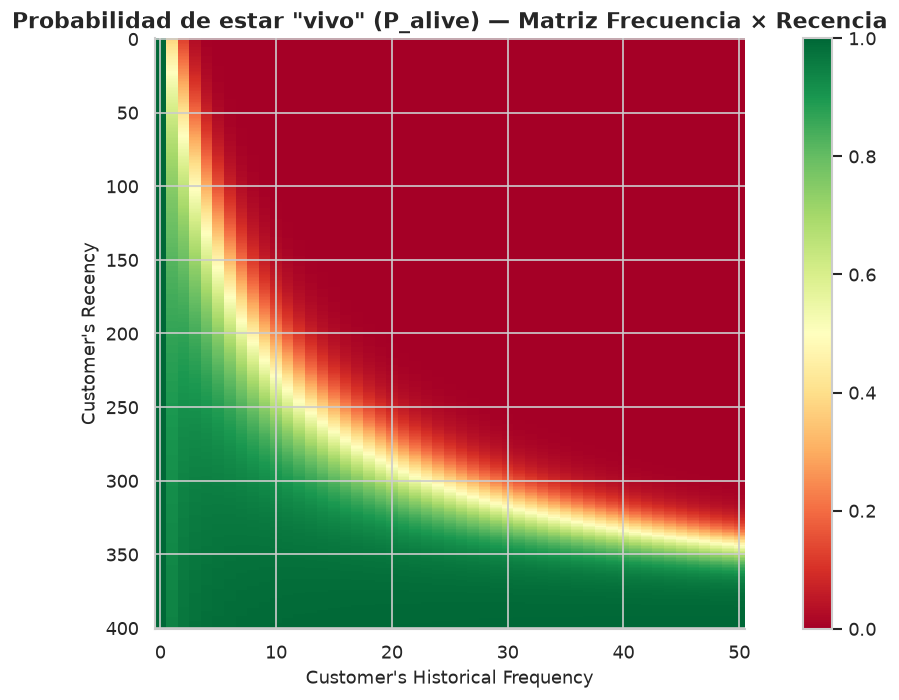

In [29]:
# ── Matriz P_alive ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
plot_probability_alive_matrix(
    bgf,
    max_frequency=50, max_recency=400,
    cmap='RdYlGn'
    # ← sin ax=ax
)
ax = plt.gca()
ax.set_title('Probabilidad de estar "vivo" (P_alive) — Matriz Frecuencia × Recencia', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bgnbd_palive_matrix.png', bbox_inches='tight')
plt.show()

### 4.3 Predicciones individuales BG/NBD

In [30]:
PREDICT_WEEKS = [4, 12, 26, 52]  # horizontes de predicción

for w in PREDICT_WEEKS:
    summary[f'pred_purchases_{w}w'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        w,
        summary['frequency'],
        summary['recency'],
        summary['T']
    )

summary['p_alive'] = bgf.conditional_probability_alive(
    summary['frequency'],
    summary['recency'],
    summary['T']
)

print("Predicciones BG/NBD (primeros 5 clientes):")
summary[['frequency','recency','T','p_alive'] + [f'pred_purchases_{w}w' for w in PREDICT_WEEKS]].head()

Predicciones BG/NBD (primeros 5 clientes):


,frequency,recency,T,p_alive,pred_purchases_4w,pred_purchases_12w,pred_purchases_26w,pred_purchases_52w
Customer ID,,,,,,,,
12346.0,7.0,400.0,726.0,0.619123,0.024041,0.072095,0.156100,0.311811
12347.0,7.0,402.0,405.0,0.989218,0.064713,0.194011,0.419880,0.838037
12348.0,4.0,363.0,439.0,0.963319,0.035768,0.107235,0.232090,0.463270
12349.0,2.0,571.0,590.0,0.964987,0.015747,0.047218,0.102217,0.204111
12350.0,0.0,0.0,311.0,1.000000,0.007122,0.021345,0.046168,0.092053


## 5 · Modelo Gamma-Gamma (valor monetario)

El modelo **Gamma-Gamma** de Fader & Hardie estima el **valor monetario esperado** por transacción para cada cliente, condicionado en que está activo.

In [31]:
# Sólo clientes con al menos 1 compra de repetición y monetary > 0
summary_gg = summary[
    (summary['frequency'] > 0) & (summary['monetary_value'] > 0)
].copy()

# Verificar correlación entre freq y monetary (debe ser baja, < 0.3)
corr = summary_gg[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f"Correlación freq–monetary: {corr:.4f}")
print(f"(Se recomienda < 0.3 para usar Gamma-Gamma)")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary_gg['frequency'], summary_gg['monetary_value'], verbose=False)

print("\n── Parámetros Gamma-Gamma ──────────────────────────────────")
print(ggf.summary.round(4).to_string())

Correlación freq–monetary: 0.0231
(Se recomienda < 0.3 para usar Gamma-Gamma)

── Parámetros Gamma-Gamma ──────────────────────────────────
      coef  se(coef)  lower 95% bound  upper 95% bound
p  11.7529    0.2255          11.3108          12.1949
q   0.8845    0.0170           0.8512           0.9178
v  11.7173    0.2304          11.2657          12.1688


In [32]:
# Valor monetario esperado por transacción
summary_gg['exp_avg_revenue'] = ggf.conditional_expected_average_profit(
    summary_gg['frequency'],
    summary_gg['monetary_value']
)

# CLV a 12 meses (discount_rate anual 10%)
summary_gg['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    summary_gg['frequency'],
    summary_gg['recency'],
    summary_gg['T'],
    summary_gg['monetary_value'],
    time=12,
    freq='W',
    discount_rate=0.01   # ~10% anual ~ 1% mensual
)

print(f"CLV 12m — mediana: £{summary_gg['clv_12m'].median():,.0f} | media: £{summary_gg['clv_12m'].mean():,.0f}")
print(f"Top 10% CLV > £{summary_gg['clv_12m'].quantile(0.90):,.0f}")
summary_gg[['exp_avg_revenue','clv_12m']].describe().round(2)

CLV 12m — mediana: £108 | media: £288
Top 10% CLV > £520


,exp_avg_revenue,clv_12m
count,4181.00,4181.00
mean,451.16,287.74
std,2688.85,1320.58
min,12.10,0.00
25%,196.97,44.18
50%,312.49,108.23
75%,455.12,254.77
max,170152.99,48124.28


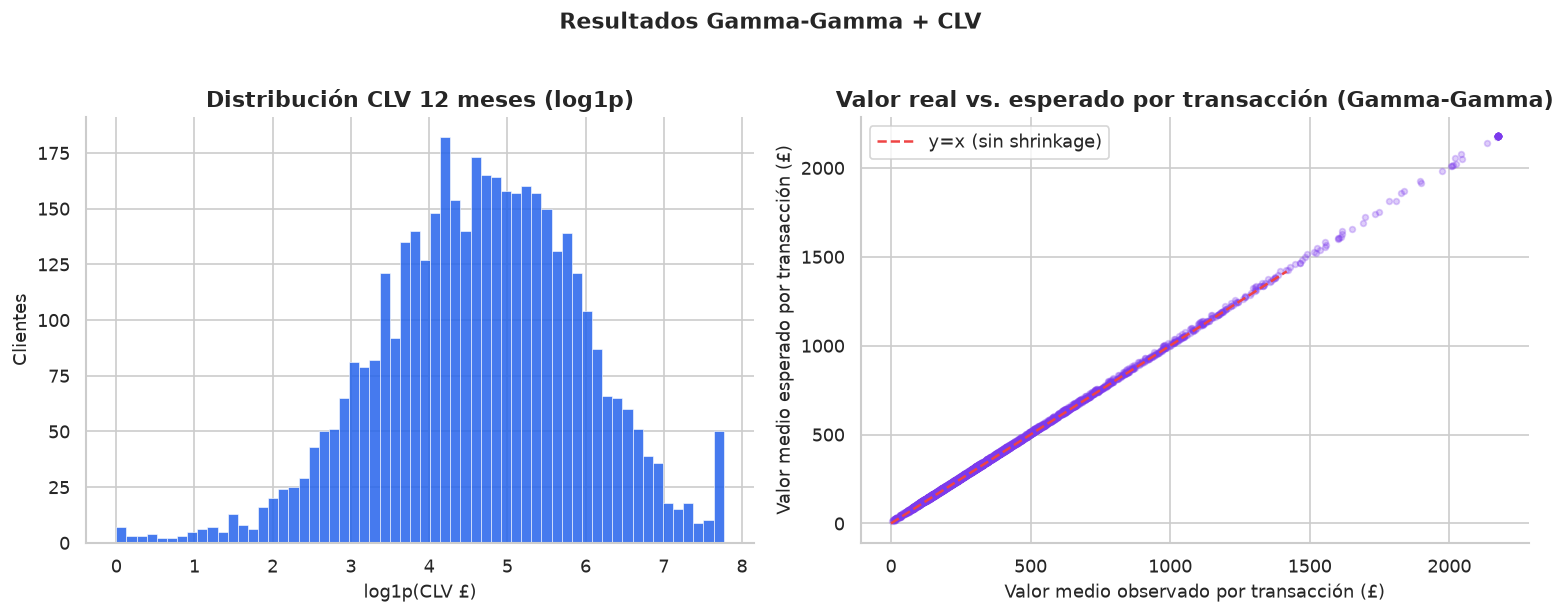

In [33]:
# ── Visualización CLV ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma CLV
axes[0].hist(
    np.log1p(summary_gg['clv_12m'].clip(upper=summary_gg['clv_12m'].quantile(0.99))),
    bins=60, color=PALETTE['primary'], alpha=0.85, edgecolor='white', linewidth=0.4
)
axes[0].set_title('Distribución CLV 12 meses (log1p)', fontweight='bold')
axes[0].set_xlabel('log1p(CLV £)')
axes[0].set_ylabel('Clientes')

# Real vs esperado por compra
axes[1].scatter(
    summary_gg['monetary_value'].clip(upper=summary_gg['monetary_value'].quantile(0.99)),
    summary_gg['exp_avg_revenue'].clip(upper=summary_gg['exp_avg_revenue'].quantile(0.99)),
    alpha=0.25, s=12, color=PALETTE['secondary']
)
lims = [0, summary_gg['monetary_value'].quantile(0.98)]
axes[1].plot(lims, lims, '--', color=PALETTE['danger'], linewidth=1.5, label='y=x (sin shrinkage)')
axes[1].set_title('Valor real vs. esperado por transacción (Gamma-Gamma)', fontweight='bold')
axes[1].set_xlabel('Valor medio observado por transacción (£)')
axes[1].set_ylabel('Valor medio esperado por transacción (£)')
axes[1].legend()

plt.suptitle('Resultados Gamma-Gamma + CLV', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gamma_gamma_clv.png', bbox_inches='tight')
plt.show()

## 6 · Perfil de cliente 360°: K-Means + BG/NBD + CLV

In [34]:
# Unir todas las predicciones con el dataframe RFM + clusters
customer_360 = (
    rfm
    .set_index('Customer ID')
    .join(summary[['p_alive'] + [f'pred_purchases_{w}w' for w in PREDICT_WEEKS]], how='left')
    .join(summary_gg[['exp_avg_revenue', 'clv_12m']], how='left')
    .reset_index()
)

print(f"Clientes en tabla 360: {len(customer_360):,}")
print(f"Con CLV calculado: {customer_360['clv_12m'].notna().sum():,} (requieren freq > 0)")
customer_360.head(3)

Clientes en tabla 360: 5,862
Con CLV calculado: 4,181 (requieren freq > 0)


,Customer ID,frequency,monetary,n_items,avg_order_value,recency,R_score,F_score,M_score,RFM_score,...,RFM_segment,cluster,cluster_label,p_alive,pred_purchases_4w,pred_purchases_12w,pred_purchases_26w,pred_purchases_52w,exp_avg_revenue,clv_12m
0,12346.0,12,77556.46,74285,6463.038333,326,2,5,5,255,...,At Risk,0,Champions,0.619123,0.024041,0.072095,0.15610,0.311811,11083.867277,3250.396805
1,12347.0,8,5633.32,3286,704.165000,2,5,4,5,545,...,Champions,0,Champions,0.989218,0.064713,0.194011,0.41988,0.838037,720.083105,567.559783
2,12348.0,5,1658.40,2704,331.680000,75,3,4,4,344,...,Loyal,0,Champions,0.963319,0.035768,0.107235,0.23209,0.463270,363.131213,158.220240


In [35]:
# ── CLV por segmento K-Means ─────────────────────────────────────────────────
clv_by_cluster = (
    customer_360.dropna(subset=['clv_12m'])
    .groupby(['cluster','cluster_label'])
    .agg(
        n              = ('Customer ID', 'count'),
        clv_median     = ('clv_12m', 'median'),
        clv_mean       = ('clv_12m', 'mean'),
        clv_total      = ('clv_12m', 'sum'),
        p_alive_mean   = ('p_alive', 'mean'),
        pred_12w_mean  = ('pred_purchases_12w', 'mean'),
    )
    .round(2)
    .sort_values('clv_total', ascending=False)
)

clv_by_cluster['clv_pct'] = (clv_by_cluster['clv_total'] / clv_by_cluster['clv_total'].sum() * 100).round(1)

print("\n── CLV por Segmento (K-Means) ──────────────────────────────")
print(clv_by_cluster.to_string())


── CLV por Segmento (K-Means) ──────────────────────────────
                          n  clv_median  clv_mean   clv_total  p_alive_mean  pred_12w_mean  clv_pct
cluster cluster_label                                                                              
0       Champions      2777      186.61    411.21  1141937.79          0.92           0.17     94.9
1       At Risk        1404       33.37     43.53    61111.85          0.78           0.06      5.1


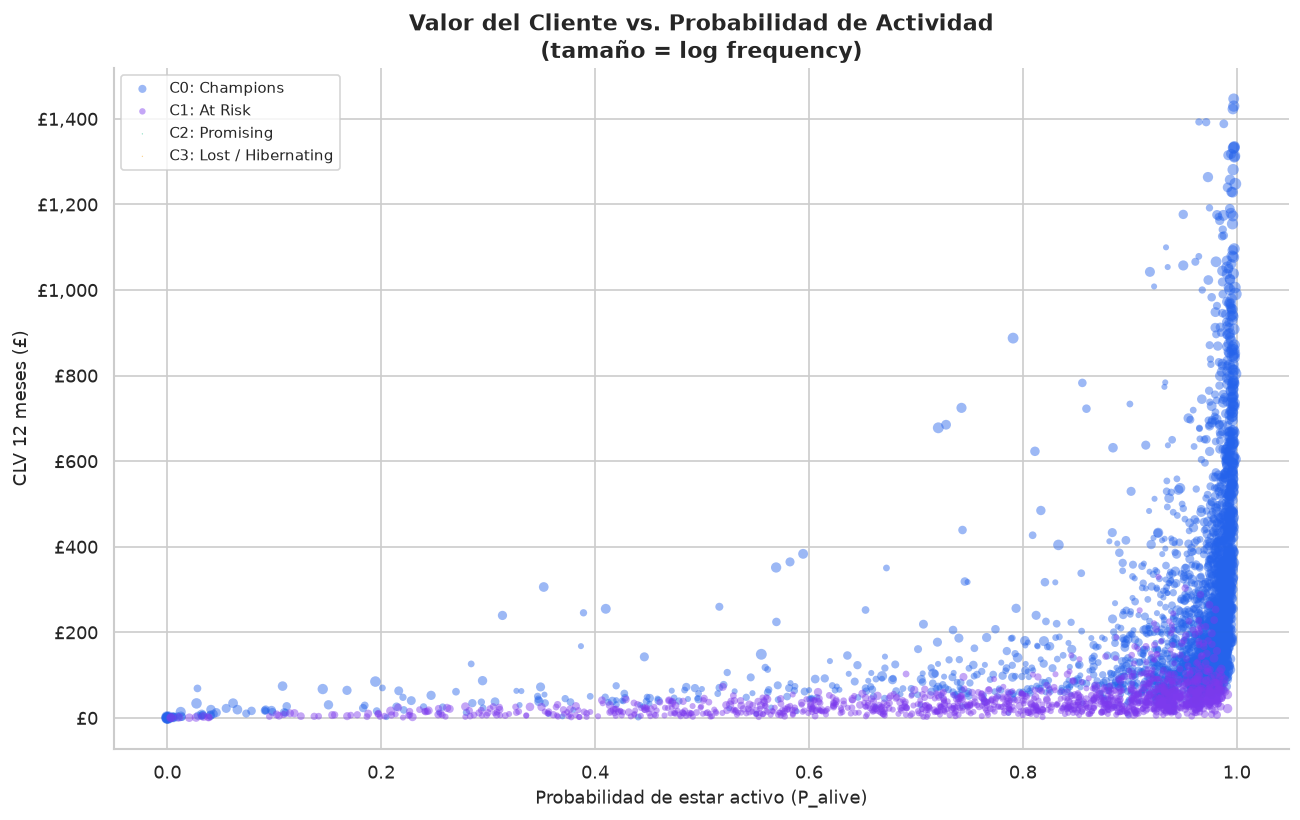

In [36]:
# ── Bubble chart: P_alive vs CLV vs Frequency ────────────────────────────────
plot_df = customer_360.dropna(subset=['clv_12m','p_alive']).copy()
plot_df = plot_df[plot_df['clv_12m'] < plot_df['clv_12m'].quantile(0.98)]  # quitar outliers

fig, ax = plt.subplots(figsize=(11, 7))

for i, (k, lbl) in enumerate(CLUSTER_LABELS.items()):
    mask = plot_df['cluster'] == k
    subset = plot_df[mask]
    ax.scatter(
        subset['p_alive'],
        subset['clv_12m'],
        c=SEGMENT_COLORS[i % len(SEGMENT_COLORS)],
        s=np.log1p(subset['frequency']) * 12,
        alpha=0.45,
        label=f'C{k}: {lbl}',
        edgecolors='none'
    )

ax.set_xlabel('Probabilidad de estar activo (P_alive)', fontsize=11)
ax.set_ylabel('CLV 12 meses (£)', fontsize=11)
ax.set_title('Valor del Cliente vs. Probabilidad de Actividad\n(tamaño = log frequency)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, markerscale=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'palive_vs_clv_bubble.png', bbox_inches='tight')
plt.show()

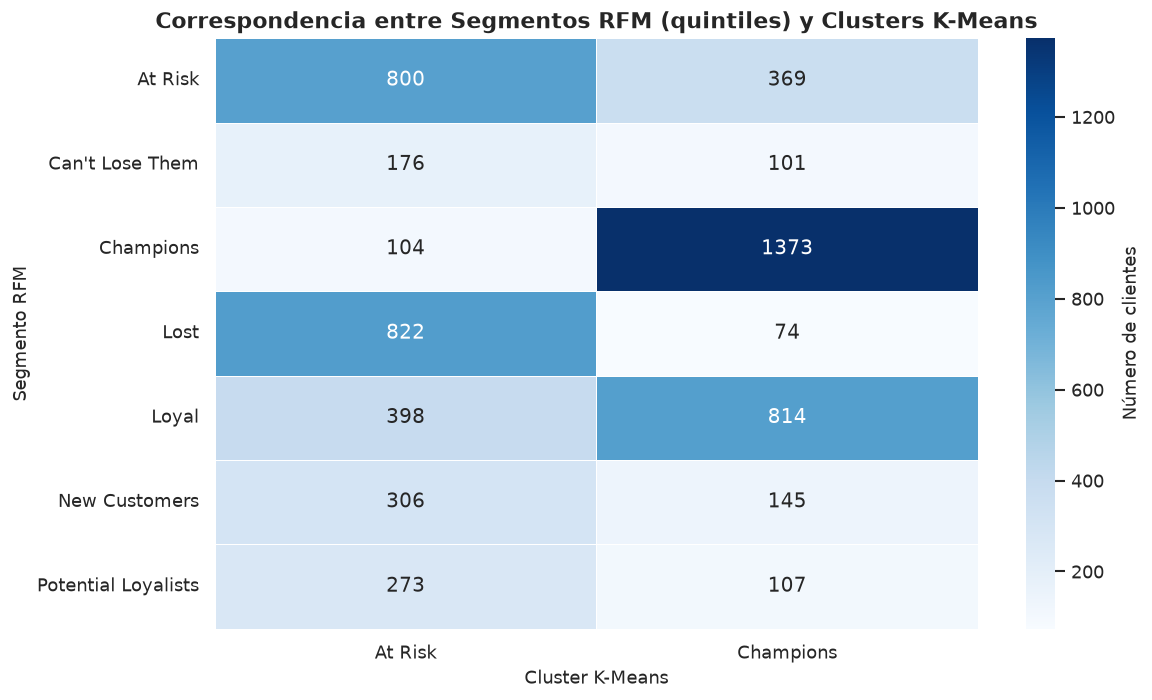

In [37]:
# ── Heatmap: RFM_segment (quintiles) vs cluster K-Means ──────────────────────
cross = pd.crosstab(customer_360['RFM_segment'], customer_360['cluster_label'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cross,
    annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Número de clientes'}
)
ax.set_title('Correspondencia entre Segmentos RFM (quintiles) y Clusters K-Means', fontweight='bold')
ax.set_xlabel('Cluster K-Means', fontsize=11)
ax.set_ylabel('Segmento RFM', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rfm_vs_kmeans_heatmap.png', bbox_inches='tight')
plt.show()

## 7 · Insights de negocio y acciones recomendadas

In [38]:
print("="*70)
print(" RESUMEN EJECUTIVO — SEGMENTACIÓN RFM + BG/NBD ")
print("="*70)

total_clv = customer_360['clv_12m'].sum()
total_customers = len(customer_360)

print(f"\n📊 Clientes analizados: {total_customers:,}")
print(f"💰 CLV total 12 meses estimado: £{total_clv:,.0f}")
print(f"   (sólo clientes con freq > 0, n={customer_360['clv_12m'].notna().sum():,})\n")

# Top 20% por CLV
top20_clv = customer_360.dropna(subset=['clv_12m']).nlargest(int(len(customer_360)*0.2), 'clv_12m')
top20_revenue_pct = top20_clv['clv_12m'].sum() / total_clv * 100
print(f"📌 Pareto CLV: el 20% superior de clientes genera {top20_revenue_pct:.1f}% del CLV total")

print("\n─── Acciones recomendadas por segmento ─────────────────────────────")
actions = {
    'Champions':          '→ Programa VIP, early access, referencias de boca a boca',
    'Loyal':              '→ Upsell / cross-sell, suscripciones, encuestas NPS',
    'At Risk':            '→ Campaña reactivación: descuento personalizado + email win-back',
    'Potential Loyalists':'→ Incentivos para segunda compra, onboarding mejorado',
    'New Customers':      '→ Secuencia de bienvenida, guías de producto, soporte proactivo',
    "Can't Lose Them":    '→ Alerta urgente, encuesta de satisfacción, oferta exclusiva',
    'Lost':               '→ Bajo ROI, campañas de reactivación muy selectivas o excluir',
}
for seg, action in actions.items():
    n_seg = (customer_360['RFM_segment'] == seg).sum()
    if n_seg > 0:
        print(f"  {seg:<22} (n={n_seg:,}) {action}")

print("\n" + "="*70)

 RESUMEN EJECUTIVO — SEGMENTACIÓN RFM + BG/NBD 

📊 Clientes analizados: 5,862
💰 CLV total 12 meses estimado: £1,203,050
   (sólo clientes con freq > 0, n=4,181)

📌 Pareto CLV: el 20% superior de clientes genera 79.5% del CLV total

─── Acciones recomendadas por segmento ─────────────────────────────
  Champions              (n=1,477) → Programa VIP, early access, referencias de boca a boca
  Loyal                  (n=1,212) → Upsell / cross-sell, suscripciones, encuestas NPS
  At Risk                (n=1,169) → Campaña reactivación: descuento personalizado + email win-back
  Potential Loyalists    (n=380) → Incentivos para segunda compra, onboarding mejorado
  New Customers          (n=451) → Secuencia de bienvenida, guías de producto, soporte proactivo
  Can't Lose Them        (n=277) → Alerta urgente, encuesta de satisfacción, oferta exclusiva
  Lost                   (n=896) → Bajo ROI, campañas de reactivación muy selectivas o excluir



## 8 · Exportar resultados

In [41]:
import json
import joblib

# ── Guardar tabla 360 completa ────────────────────────────────────────────────
output_path = DATA_DIR / 'customer_360.parquet'
customer_360.to_parquet(output_path, index=False)
print(f"✅ customer_360.parquet guardado → {output_path}")

# ── Guardar parámetros BG/NBD (no serializable con pickle/joblib) ─────────────
bgf_params = {k: float(v) for k, v in bgf.params_.items()}
with open(OUTPUT_DIR / 'bgf_params.json', 'w') as f:
    json.dump(bgf_params, f, indent=2)
print(f"✅ bgf_params.json: {bgf_params}")

# ── Guardar parámetros Gamma-Gamma ────────────────────────────────────────────
ggf_params = {k: float(v) for k, v in ggf.params_.items()}
with open(OUTPUT_DIR / 'ggf_params.json', 'w') as f:
    json.dump(ggf_params, f, indent=2)
print(f"✅ ggf_params.json: {ggf_params}")

# ── K-Means y Scaler sí son serializables con joblib ─────────────────────────
joblib.dump(km_final, OUTPUT_DIR / 'kmeans_model.joblib')
joblib.dump(scaler,   OUTPUT_DIR / 'robust_scaler.joblib')
print("✅ kmeans_model.joblib + robust_scaler.joblib guardados")

✅ customer_360.parquet guardado → data\processed\customer_360.parquet
✅ bgf_params.json: {'r': 0.6674348779441132, 'alpha': 63.668100569376, 'a': 0.07511566650810268, 'b': 1.2397083396368855}
✅ ggf_params.json: {'p': 11.75287082752865, 'q': 0.8845336822118405, 'v': 11.717261202375417}
✅ kmeans_model.joblib + robust_scaler.joblib guardados


In [42]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print("\n📦 Archivos generados en outputs/03_rfm/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name:<45} {size_kb:>7.1f} KB")

print("\n✅ Notebook 03 completado.")
print("   Siguiente paso → Notebook 04: Dashboard interactivo (Plotly/Streamlit)")


📦 Archivos generados en outputs/03_rfm/:
   bgf_model.joblib                                185.0 KB
   bgf_model.pkl                                   184.7 KB
   bgf_params.json                                   0.1 KB
   bgnbd_frequency_recency_matrix.png               46.5 KB
   bgnbd_palive_matrix.png                          53.1 KB
   bgnbd_period_transactions.png                    31.9 KB
   gamma_gamma_clv.png                              74.8 KB
   ggf_params.json                                   0.1 KB
   kmeans_boxplots.png                              57.3 KB
   kmeans_k_selection.png                           91.9 KB
   kmeans_model.joblib                              23.7 KB
   kmeans_pca_scatter.png                          233.1 KB
   kmeans_radar_profile.png                         72.2 KB
   palive_vs_clv_bubble.png                        173.2 KB
   rfm_distributions.png                            52.1 KB
   rfm_treemap.png                                  34.3 K

---
## Notas metodológicas

| Aspecto | Decisión | Justificación |
|---|---|---|
| Scaler | RobustScaler | Resistente a outliers en monetary (cola larga) |
| Transformación | log1p en F y M | Reduce skewness antes del escalado |
| Init K-Means | `k-means++` | Convergencia más rápida y estable |
| n_init | 50 | Evita mínimos locales |
| Penalizer BG/NBD | 0.001 | Regularización ligera para datasets medianos |
| Discount rate | 1%/mes (~10% anual) | Valor estándar en retail e-commerce |
| Horizonte CLV | 12 meses | Horizonte planificación marketing habitual |

### Limitaciones
- El BG/NBD asume que el proceso de compra es **no contractual** y estacionario (tasas $\lambda$ y $\mu$ constantes en el tiempo).
- El Gamma-Gamma asume **independencia** entre la frecuencia de compra y el valor monetario por transacción.
- Los modelos se ajustan sobre el período completo; en producción, usar walk-forward validation (e.g., entrenar en 2009-2010, validar en 2011).